<a href="https://colab.research.google.com/github/diana499/BAESANDIANAlab7/blob/master/ProiectBigData.ipynb" target="_parent"><img src="https://colab.research.google.com/assets/colab-badge.svg" alt="Open In Colab"/></a>

# 1. Introducere si obiectiv
Scopul proiectului este realizarea unui model de învățare automată care prezice dacă o persoană are sau nu risc de boală cardiacă, folosind caracteristici medicale precum vârsta, tensiunea arterială, colesterolul, pulsul maxim și alte informații clinice.

Problema este una de clasificare, deoarece variabila țintă este target, care are două clase: 0 = fără boală cardiacă și 1 = prezența bolii cardiace.

# 2. Importarea bibliotecilor
În această etapă importăm bibliotecile necesare pentru manipularea datelor, vizualizare, preprocesare, antrenarea modelelor și evaluarea performanței.

In [7]:
import pandas as pd
import numpy as np

import matplotlib.pyplot as plt
import seaborn as sns

from sklearn.model_selection import train_test_split

from sklearn.preprocessing import StandardScaler
from sklearn.pipeline import Pipeline
from sklearn.impute import SimpleImputer

from sklearn.linear_model import LogisticRegression
from sklearn.tree import DecisionTreeClassifier
from sklearn.ensemble import RandomForestClassifier
from sklearn.naive_bayes import GaussianNB

from sklearn.metrics import accuracy_score, precision_score, recall_score, f1_score
from sklearn.metrics import classification_report, confusion_matrix

# 3. Încărcarea datasetului
Datasetul folosit este Heart Disease Dataset, disponibil public pe Kaggle. Acesta conține informații medicale despre pacienți și este potrivit pentru o problemă de clasificare, deoarece variabila target indică prezența sau absența bolii cardiace.


Această comandă afișează primele rânduri din dataset. Ne ajută să observăm structura datelor și exemple de valori pentru fiecare coloană.

In [9]:
df = pd.read_csv("heart.csv")
df.head()

,age,sex,cp,trestbps,chol,fbs,restecg,thalach,exang,oldpeak,slope,ca,thal,target
0,52,1,0,125,212,0,1,168,0,1.0,2,2,3,0
1,53,1,0,140,203,1,0,155,1,3.1,0,0,3,0
2,70,1,0,145,174,0,1,125,1,2.6,0,0,3,0
3,61,1,0,148,203,0,1,161,0,0.0,2,1,3,0
4,62,0,0,138,294,1,1,106,0,1.9,1,3,2,0


# 4. Explorarea inițială a datelor
În această secțiune analizăm structura generală a datasetului, pentru a înțelege numărul de înregistrări, coloanele disponibile, tipurile de date și statisticile descriptive.


Această comandă afișează dimensiunea datasetului, adică numărul de rânduri și numărul de coloane.

In [10]:
df.shape

(1025, 14)

Această comandă afișează numele tuturor coloanelor din dataset. Ne ajută să identificăm variabilele disponibile.

In [11]:
df.columns

Index(['age', 'sex', 'cp', 'trestbps', 'chol', 'fbs', 'restecg', 'thalach',
       'exang', 'oldpeak', 'slope', 'ca', 'thal', 'target'],
      dtype='object')

Această comandă oferă informații despre tipul fiecărei coloane și despre valorile lipsă. Este utilă pentru înțelegerea structurii datasetului.

In [12]:
df.info()

<class 'pandas.core.frame.DataFrame'>
RangeIndex: 1025 entries, 0 to 1024
Data columns (total 14 columns):
 #   Column    Non-Null Count  Dtype  
---  ------    --------------  -----  
 0   age       1025 non-null   int64  
 1   sex       1025 non-null   int64  
 2   cp        1025 non-null   int64  
 3   trestbps  1025 non-null   int64  
 4   chol      1025 non-null   int64  
 5   fbs       1025 non-null   int64  
 6   restecg   1025 non-null   int64  
 7   thalach   1025 non-null   int64  
 8   exang     1025 non-null   int64  
 9   oldpeak   1025 non-null   float64
 10  slope     1025 non-null   int64  
 11  ca        1025 non-null   int64  
 12  thal      1025 non-null   int64  
 13  target    1025 non-null   int64  
dtypes: float64(1), int64(13)
memory usage: 112.2 KB


Această comandă afișează statistici descriptive pentru coloanele numerice, precum media, minimul, maximul și quartilele.

In [13]:
df.describe()

,age,sex,cp,trestbps,chol,fbs,restecg,thalach,exang,oldpeak,slope,ca,thal,target
count,1025.000000,1025.000000,1025.000000,1025.000000,1025.00000,1025.000000,1025.000000,1025.000000,1025.000000,1025.000000,1025.000000,1025.000000,1025.000000,1025.000000
mean,54.434146,0.695610,0.942439,131.611707,246.00000,0.149268,0.529756,149.114146,0.336585,1.071512,1.385366,0.754146,2.323902,0.513171
std,9.072290,0.460373,1.029641,17.516718,51.59251,0.356527,0.527878,23.005724,0.472772,1.175053,0.617755,1.030798,0.620660,0.500070
min,29.000000,0.000000,0.000000,94.000000,126.00000,0.000000,0.000000,71.000000,0.000000,0.000000,0.000000,0.000000,0.000000,0.000000
25%,48.000000,0.000000,0.000000,120.000000,211.00000,0.000000,0.000000,132.000000,0.000000,0.000000,1.000000,0.000000,2.000000,0.000000
50%,56.000000,1.000000,1.000000,130.000000,240.00000,0.000000,1.000000,152.000000,0.000000,0.800000,1.000000,0.000000,2.000000,1.000000
75%,61.000000,1.000000,2.000000,140.000000,275.00000,0.000000,1.000000,166.000000,1.000000,1.800000,2.000000,1.000000,3.000000,1.000000
max,77.000000,1.000000,3.000000,200.000000,564.00000,1.000000,2.000000,202.000000,1.000000,6.200000,2.000000,4.000000,3.000000,1.000000


# 5. Curățarea datelor
În această etapă verificăm calitatea datelor. Analizăm dacă există valori lipsă sau rânduri duplicate, deoarece acestea pot influența negativ performanța modelelor.


Această comandă verifică dacă există valori lipsă în fiecare coloană.

In [14]:
df.isnull().sum()

,0
age,0
sex,0
cp,0
trestbps,0
chol,0
fbs,0
restecg,0
thalach,0
exang,0
oldpeak,0


Această comandă verifică dacă există rânduri duplicate în dataset.

In [39]:
df.duplicated().sum()

np.int64(0)

Această comandă elimină rândurile duplicate, pentru ca modelul să fie antrenat pe date curate.

In [16]:
df = df.drop_duplicates()
df.shape

(302, 14)

# 6. Analiza variabilei țintă
În această secțiune analizăm distribuția variabilei țintă. Acest lucru ne ajută să observăm dacă există dezechilibru între clase.

In [17]:
df['target'].value_counts()

,count
target,
1,164
0,138


Acest grafic arată distribuția claselor din variabila target. Clasa 0 reprezintă persoanele fără boală cardiacă, iar clasa 1 reprezintă persoanele cu boală cardiacă.

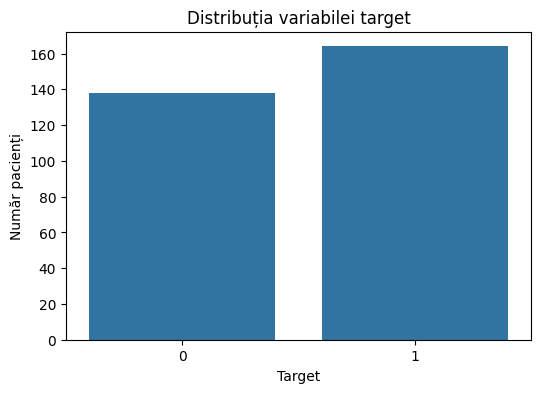

In [18]:
plt.figure(figsize=(6,4))
sns.countplot(data=df, x='target')
plt.title("Distribuția variabilei target")
plt.xlabel("Target")
plt.ylabel("Număr pacienți")
plt.show()

# 7. Vizualizarea datelor
În această secțiune folosim grafice pentru a înțelege relația dintre anumite caracteristici medicale și prezența bolii cardiace.


Acest grafic compară vârsta pacienților în funcție de prezența bolii cardiace.

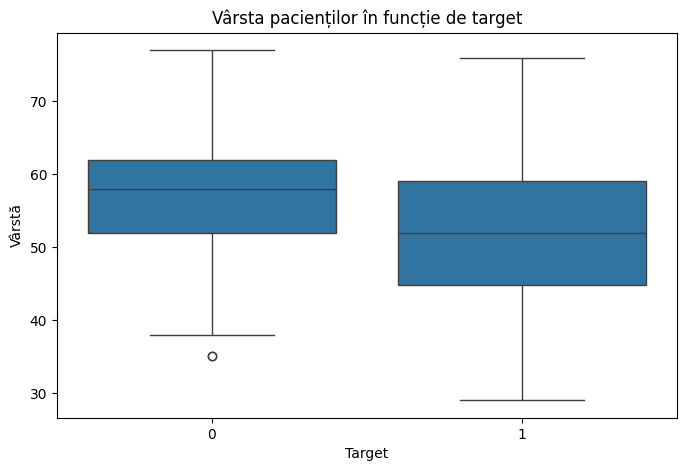

In [19]:
plt.figure(figsize=(8,5))
sns.boxplot(data=df, x='target', y='age')
plt.title("Vârsta pacienților în funcție de target")
plt.xlabel("Target")
plt.ylabel("Vârstă")
plt.show()

Acest grafic compară colesterolul pacienților în funcție de prezența bolii cardiace.

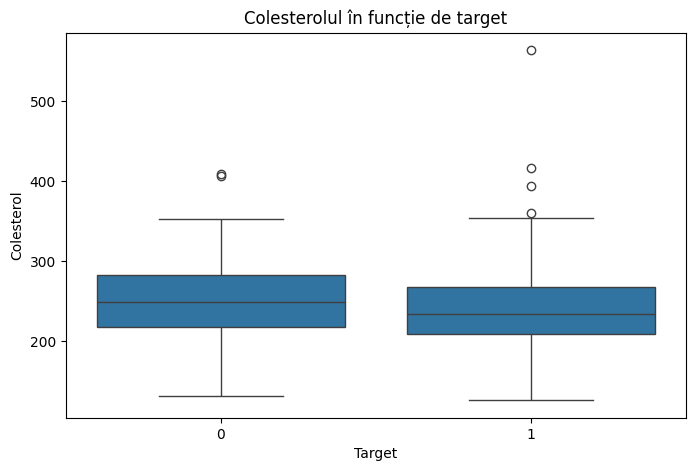

In [20]:
plt.figure(figsize=(8,5))
sns.boxplot(data=df, x='target', y='chol')
plt.title("Colesterolul în funcție de target")
plt.xlabel("Target")
plt.ylabel("Colesterol")
plt.show()

Acest grafic compară pulsul maxim atins în funcție de prezența bolii cardiace.

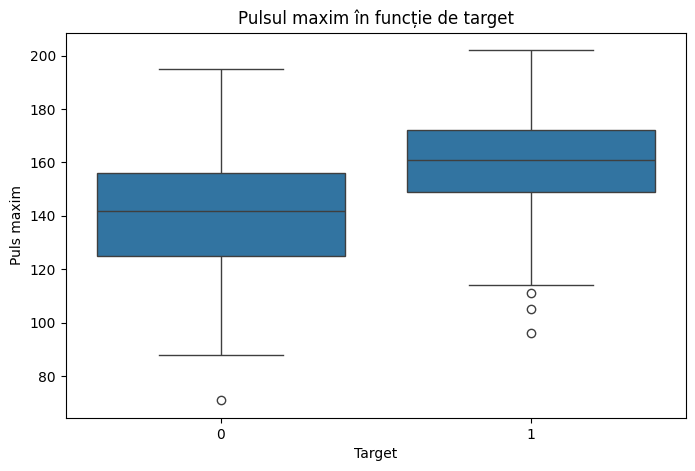

In [21]:
plt.figure(figsize=(8,5))
sns.boxplot(data=df, x='target', y='thalach')
plt.title("Pulsul maxim în funcție de target")
plt.xlabel("Target")
plt.ylabel("Puls maxim")
plt.show()

Matricea de corelație arată relațiile dintre variabilele numerice din dataset. Valorile apropiate de 1 indică relații pozitive puternice, iar valorile apropiate de -1 indică relații negative puternice.

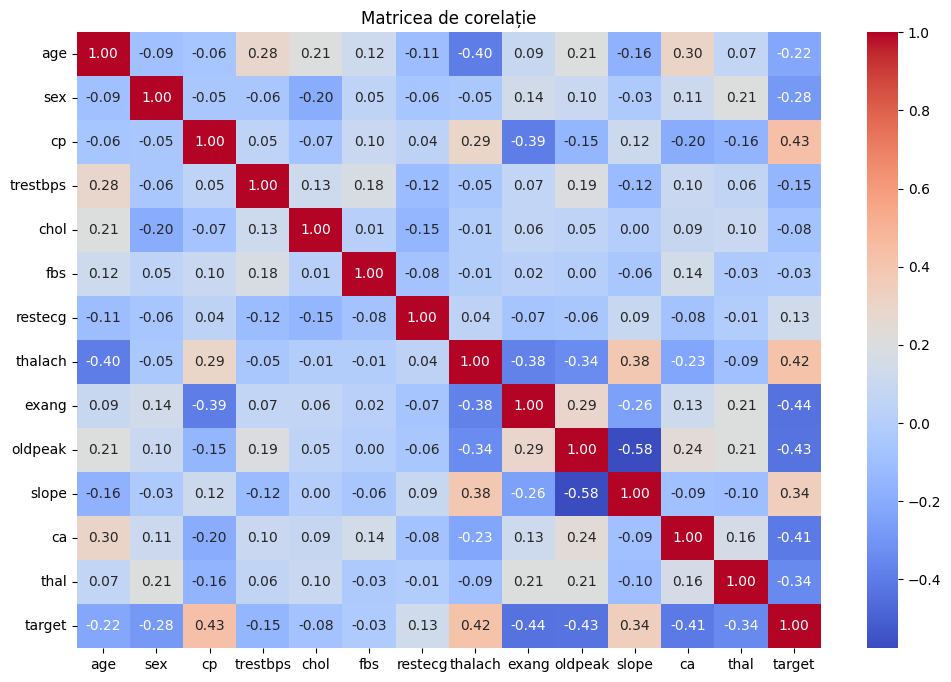

In [22]:
plt.figure(figsize=(12,8))
sns.heatmap(df.corr(), annot=True, cmap='coolwarm', fmt=".2f")
plt.title("Matricea de corelație")
plt.show()

# 8. Separarea variabilelor
În această etapă separăm variabilele de intrare de variabila țintă. Variabilele de intrare conțin caracteristicile medicale ale pacienților, iar variabila țintă este target.

In [23]:
X = df.drop('target', axis=1)
y = df['target']

# 9. Împărțirea datelor
Datele sunt împărțite în set de antrenare și set de testare. Setul de antrenare este utilizat pentru construirea modelului, iar setul de testare pentru evaluarea performanței acestuia. În proiect s-a folosit o împărțire de 80% pentru antrenare și 20% pentru testare.

In [24]:
X_train, X_test, y_train, y_test = train_test_split(
    X, y, test_size=0.2, random_state=42, stratify=y
)

# 10. Preprocesarea datelor
În această etapă sunt pregătite datele pentru antrenarea modelelor. Valorile lipsă sunt completate cu mediana, iar valorile numerice sunt standardizate. Standardizarea este utilă mai ales pentru modele precum Logistic Regression și Gaussian Naive Bayes.

In [25]:
preprocessor = Pipeline(steps=[
    ('imputer', SimpleImputer(strategy='median')),
    ('scaler', StandardScaler())
])

# 11. Funcția de evaluare

Această funcție antrenează modelul pe setul de antrenare, realizează predicții pe setul de testare și calculează metricile de clasificare: accuracy, precision, recall și F1-score.

In [26]:
def evaluate_model(model, X_train, X_test, y_train, y_test, model_name):
    model.fit(X_train, y_train)
    predictions = model.predict(X_test)

    accuracy = accuracy_score(y_test, predictions)
    precision = precision_score(y_test, predictions)
    recall = recall_score(y_test, predictions)
    f1 = f1_score(y_test, predictions)

    print(model_name)
    print("Accuracy:", accuracy)
    print("Precision:", precision)
    print("Recall:", recall)
    print("F1-score:", f1)
    print("-" * 40)

    return {
        "Model": model_name,
        "Accuracy": accuracy,
        "Precision": precision,
        "Recall": recall,
        "F1-score": f1
    }

# 12. Definirea modelelor

În această etapă sunt create modelele de clasificare care vor fi testate. Fiecare model este inclus într-un Pipeline, astfel încât preprocesarea datelor și antrenarea modelului să fie realizate împreună.

In [27]:
logistic_model = Pipeline(steps=[
    ('preprocessor', preprocessor),
    ('classifier', LogisticRegression(max_iter=1000))
])

decision_tree_model = Pipeline(steps=[
    ('preprocessor', preprocessor),
    ('classifier', DecisionTreeClassifier(random_state=42))
])

random_forest_model = Pipeline(steps=[
    ('preprocessor', preprocessor),
    ('classifier', RandomForestClassifier(random_state=42, n_estimators=100))
])

naive_bayes_model = Pipeline(steps=[
    ('preprocessor', preprocessor),
    ('classifier', GaussianNB())
])

# 13. Antrenarea și evaluarea modelelor

În această etapă modelele sunt antrenate pe setul de antrenare și evaluate pe setul de testare. Pentru fiecare model sunt calculate accuracy, precision, recall și F1-score.

In [28]:
results = []

results.append(evaluate_model(logistic_model, X_train, X_test, y_train, y_test, "Logistic Regression"))
results.append(evaluate_model(decision_tree_model, X_train, X_test, y_train, y_test, "Decision Tree Classifier"))
results.append(evaluate_model(random_forest_model, X_train, X_test, y_train, y_test, "Random Forest Classifier"))
results.append(evaluate_model(naive_bayes_model, X_train, X_test, y_train, y_test, "Gaussian Naive Bayes"))

Logistic Regression
Accuracy: 0.8032786885245902
Precision: 0.8
Recall: 0.8484848484848485
F1-score: 0.8235294117647058
----------------------------------------
Decision Tree Classifier
Accuracy: 0.8032786885245902
Precision: 0.8181818181818182
Recall: 0.8181818181818182
F1-score: 0.8181818181818182
----------------------------------------
Random Forest Classifier
Accuracy: 0.7540983606557377
Precision: 0.7647058823529411
Recall: 0.7878787878787878
F1-score: 0.7761194029850746
----------------------------------------
Gaussian Naive Bayes
Accuracy: 0.7868852459016393
Precision: 0.8333333333333334
Recall: 0.7575757575757576
F1-score: 0.7936507936507936
----------------------------------------


# 14. Compararea rezultatelor

Acest tabel centralizează rezultatele obținute de fiecare model de clasificare. Sunt afișate valorile pentru accuracy, precision, recall și F1-score, pentru a putea compara performanța modelelor.

In [29]:
results_df = pd.DataFrame(results)
results_df

,Model,Accuracy,Precision,Recall,F1-score
0,Logistic Regression,0.803279,0.800000,0.848485,0.823529
1,Decision Tree Classifier,0.803279,0.818182,0.818182,0.818182
2,Random Forest Classifier,0.754098,0.764706,0.787879,0.776119
3,Gaussian Naive Bayes,0.786885,0.833333,0.757576,0.793651


Acest grafic compară modelele folosind F1-score. F1-score combină precision și recall și este util pentru evaluarea echilibrată a modelelor de clasificare.

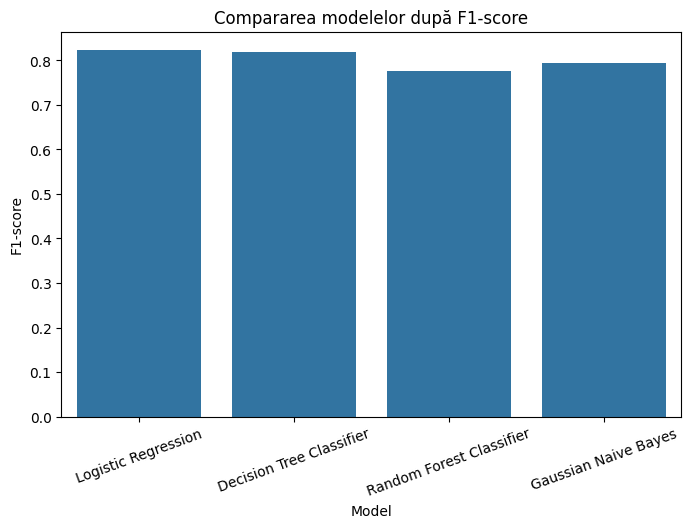

In [30]:
plt.figure(figsize=(8,5))
sns.barplot(data=results_df, x='Model', y='F1-score')
plt.title("Compararea modelelor după F1-score")
plt.xticks(rotation=20)
plt.show()

Acest grafic compară modelele folosind accuracy. Accuracy arată proporția predicțiilor corecte din totalul predicțiilor.

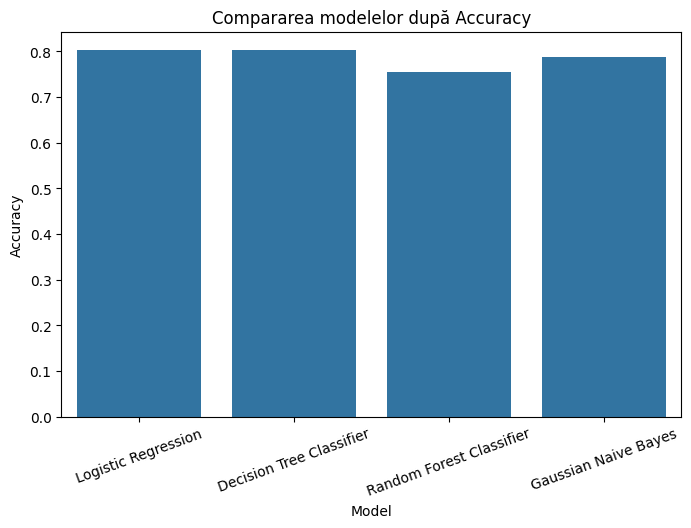

In [31]:
plt.figure(figsize=(8,5))
sns.barplot(data=results_df, x='Model', y='Accuracy')
plt.title("Compararea modelelor după Accuracy")
plt.xticks(rotation=20)
plt.show()

Acest grafic compară modelele folosind accuracy. Accuracy arată proporția predicțiilor corecte din totalul predicțiilor.

In [32]:
best_result = results_df.sort_values(by='F1-score', ascending=False).iloc[0]
best_result

,0
Model,Logistic Regression
Accuracy,0.803279
Precision,0.8
Recall,0.848485
F1-score,0.823529


In [33]:
best_model = random_forest_model
best_model.fit(X_train, y_train)

y_pred = best_model.predict(X_test)

# 16. Matricea de confuzie
Matricea de confuzie arată câte predicții au fost corecte și câte au fost greșite pentru fiecare clasă. Este utilă pentru a observa dacă modelul identifică bine pacienții cu și fără boală cardiacă.

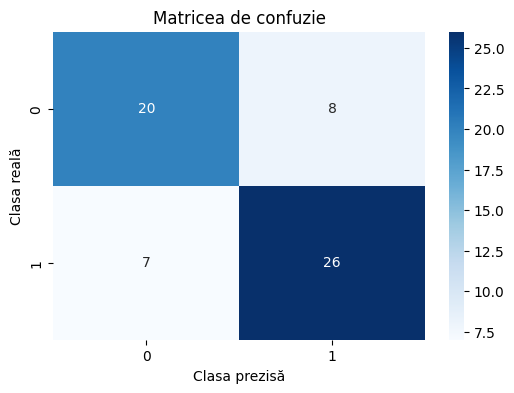

In [34]:
cm = confusion_matrix(y_test, y_pred)

plt.figure(figsize=(6,4))
sns.heatmap(cm, annot=True, fmt='d', cmap='Blues',
            xticklabels=best_model.classes_,
            yticklabels=best_model.classes_)
plt.title("Matricea de confuzie")
plt.xlabel("Clasa prezisă")
plt.ylabel("Clasa reală")
plt.show()

In [36]:
from sklearn.metrics import roc_curve, roc_auc_score

Curba ROC arată performanța modelului pentru diferite praguri de clasificare. Cu cât curba este mai apropiată de colțul stânga-sus, cu atât modelul are performanță mai bună.

Scorul AUC indică abilitatea modelului de a diferenția între pacienții cu și fără boală cardiacă.

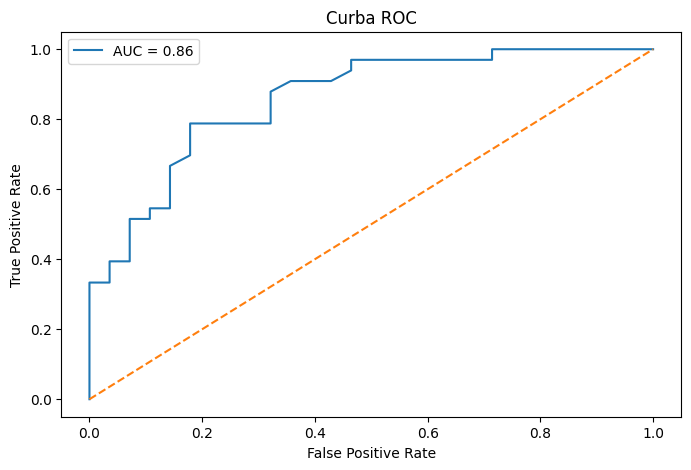

In [37]:
y_prob = best_model.predict_proba(X_test)[:, 1]

fpr, tpr, thresholds = roc_curve(y_test, y_prob)

auc_score = roc_auc_score(y_test, y_prob)

plt.figure(figsize=(8,5))
plt.plot(fpr, tpr, label=f'AUC = {auc_score:.2f}')
plt.plot([0,1], [0,1], linestyle='--')

plt.title("Curba ROC")
plt.xlabel("False Positive Rate")
plt.ylabel("True Positive Rate")
plt.legend()
plt.show()

# 17. Raport de clasificare
Raportul de clasificare afișează precision, recall și F1-score pentru fiecare clasă. Acesta oferă o imagine mai detaliată asupra performanței modelului final.

In [38]:
print(classification_report(y_test, y_pred))

              precision    recall  f1-score   support

           0       0.74      0.71      0.73        28
           1       0.76      0.79      0.78        33

    accuracy                           0.75        61
   macro avg       0.75      0.75      0.75        61
weighted avg       0.75      0.75      0.75        61



# 18. Concluzii

În urma evaluării, modelul final a fost ales pe baza valorii F1-score, deoarece această metrică oferă un echilibru între precision și recall.

Modelul poate fi utilizat pentru estimarea riscului de boală cardiacă pe baza unor caracteristici medicale. Totuși, rezultatele trebuie interpretate cu atenție, deoarece modelul nu reprezintă un instrument medical de diagnostic, ci doar un sistem de predicție bazat pe date.

Punctul forte al proiectului este compararea mai multor algoritmi de clasificare. O limitare importantă este faptul că predicțiile depind de dimensiunea și calitatea datasetului.